**Name :-** Om Dipak Patil  
**GH Number :-** GH1044372  
**Module Name :-** M515A Ethical Issues for AI

# Algorithmic Fairness Analysis
## UCI Adult Income Dataset

### Introduction

This notebook investigates **algorithmic fairness** using the UCI Adult Income dataset. The goal is to train a binary classifier that predicts whether an individual earns more than \$50K per year, then audit the model for discriminatory behaviour across protected demographic groups.


---
## 1  |  Imports & Configuration

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

---
## 2  |  Data Loading

In [3]:
df = pd.read_csv('adult.data.csv')
print(f'Shape: {df.shape}')  
df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
# Distribution of the target variable
print('Target distribution:')
print(df['salary'].value_counts())
print(f"\nClass balance: {df['salary'].value_counts(normalize=True).round(3).to_dict()}")

Target distribution:
salary
<=50K    24720
>50K      7841
Name: count, dtype: int64

Class balance: {'<=50K': 0.759, '>50K': 0.241}


---
## 3  |  Preprocessing

In [5]:
for col in df.columns:
    if df[col].dtype == object or str(df[col].dtype) == 'str':
        df[col] = df[col].str.strip()

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

print('Missing values per column:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values found.')

Missing values per column:
workclass         1836
occupation        1843
native-country     583
dtype: int64


In [6]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Rows after dropping missing values: {len(df):,}')

Rows after dropping missing values: 30,162


In [7]:
sex_col  = df['sex'].copy()   
race_col = df['race'].copy()
print('Sex groups :', sex_col.unique())
print('Race groups:', race_col.unique())

Sex groups : ['Male' 'Female']
Race groups: ['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']


In [8]:
#  Encode categorical features 
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == object or str(df[col].dtype) == 'str':
        df[col] = le.fit_transform(df[col])
print('Sample of encoded dataframe:')
df.head(3)

Sample of encoded dataframe:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,5,77516,9,13,4,0,1,4,1,2174,0,40,38,0
1,50,4,83311,9,13,2,3,0,4,1,0,0,13,38,0
2,38,2,215646,11,9,0,5,1,4,1,0,0,40,38,0


In [13]:
#  Separate features (X) and target (y) 
X = df.drop(columns=['salary'])
y = df['salary']
print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')

Features shape : (30162, 14)
Target shape   : (30162,)


In [15]:
#  Train / test split (80 / 20) 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)
sex_test  = sex_col.loc[X_test.index].reset_index(drop=True)
race_test = race_col.loc[X_test.index].reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f'Train size : {len(X_train):,}')
print(f'Test size  : {len(X_test):,}')

Train size : 24,129
Test size  : 6,033


In [16]:
# Logistic Regression is sensitive to feature magnitude.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  

---
## 4  |  Model Training

In [17]:
# Logistic Regression — simple, interpretable, well-suited for binary classification.
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)
# Generate predictions on the held-out test set
y_pred = model.predict(X_test_scaled)
print('Model trained successfully.')

Model trained successfully.


---
## 5  |  Overall Model Evaluation

In [18]:
#  Overall Accuracy 
acc = accuracy_score(y_test, y_pred)
print(f'Overall Accuracy: {acc:.4f}  ({acc * 100:.2f}%)')

Overall Accuracy: 0.8175  (81.75%)


In [19]:
#  Classification Report 

print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

              precision    recall  f1-score   support

       <=50K       0.84      0.94      0.89      4531
        >50K       0.71      0.45      0.55      1502

    accuracy                           0.82      6033
   macro avg       0.78      0.69      0.72      6033
weighted avg       0.81      0.82      0.80      6033



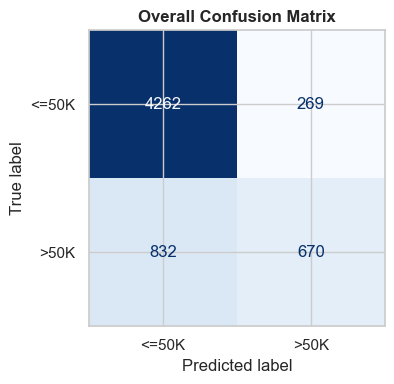

In [20]:
#   Overall Confusion Matrix 
cm_overall = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=cm_overall,
    display_labels=['<=50K', '>50K']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Overall Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6  |  Fairness Analysis — by Sex

### Reusable Fairness Metrics Function

The helper below is the core building block for all fairness analyses. It takes any ground-truth / prediction pair and returns the four error-rate metrics.

In [22]:
def calculate_fairness_metrics(y_true, y_pred):
    # sklearn returns the matrix as [[TN, FP], [FN, TP]]
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    # Guard against division by zero — return 0.0 when denominator is zero
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    FNR = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    FDR = FP / (FP + TP) if (FP + TP) > 0 else 0.0
    FOR = FN / (FN + TN) if (FN + TN) > 0 else 0.0

    return {
        'FPR': round(FPR, 4),
        'FNR': round(FNR, 4),
        'FDR': round(FDR, 4),
        'FOR': round(FOR, 4),
        'n'  : int(len(y_true)),
    }

print('calculate_fairness_metrics() is ready.')

calculate_fairness_metrics() is ready.


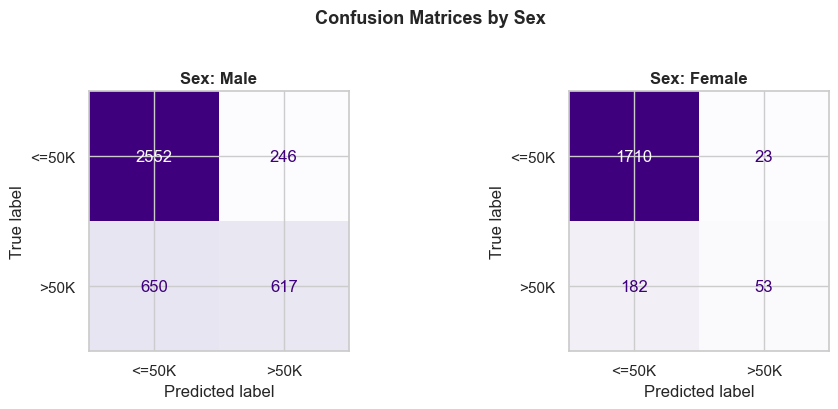

In [23]:
#   Confusion matrices per sex group 
sex_groups = sex_test.unique()

fig, axes = plt.subplots(1, len(sex_groups), figsize=(10, 4))

for ax, group in zip(axes, sex_groups):
    mask = (sex_test == group).values          # numpy boolean array — safe for indexing
    cm_g = confusion_matrix(y_test.values[mask], y_pred[mask])
    ConfusionMatrixDisplay(
        confusion_matrix=cm_g,
        display_labels=['<=50K', '>50K']
    ).plot(ax=ax, colorbar=False, cmap='Purples')
    ax.set_title(f'Sex: {group}', fontweight='bold')

plt.suptitle('Confusion Matrices by Sex', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# Fairness metrics table for sex 
sex_metrics = {}
for group in sex_groups:
    mask = (sex_test == group).values          # convert to numpy to avoid index issues
    sex_metrics[group] = calculate_fairness_metrics(
        y_test.values[mask],
        y_pred[mask],
    )
sex_df = pd.DataFrame(sex_metrics).T
sex_df.index.name = 'Group'
sex_df

,FPR,FNR,FDR,FOR,n
Group,,,,,
Male,0.0879,0.5130,0.2851,0.2030,4065.0
Female,0.0133,0.7745,0.3026,0.0962,1968.0


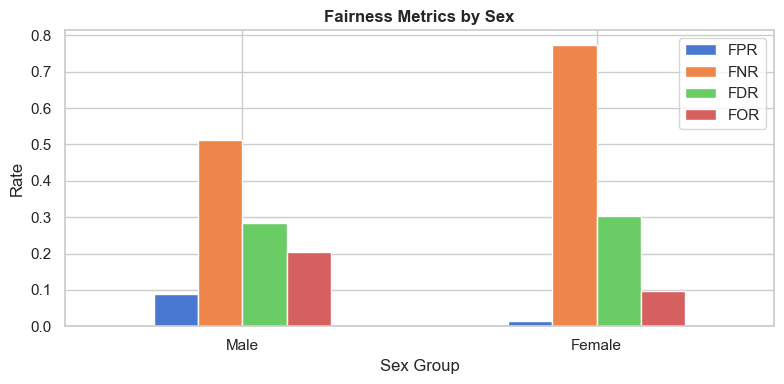

In [26]:
#  Bar chart — error rates by sex 
metrics_cols = ['FPR', 'FNR', 'FDR', 'FOR']

ax = sex_df[metrics_cols].plot(
    kind='bar',
    figsize=(8, 4),
    rot=0,
    edgecolor='white',
)
ax.set_title('Fairness Metrics by Sex', fontweight='bold')
ax.set_ylabel('Rate')
ax.set_xlabel('Sex Group')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
## 7  |  Fairness Analysis — by Race

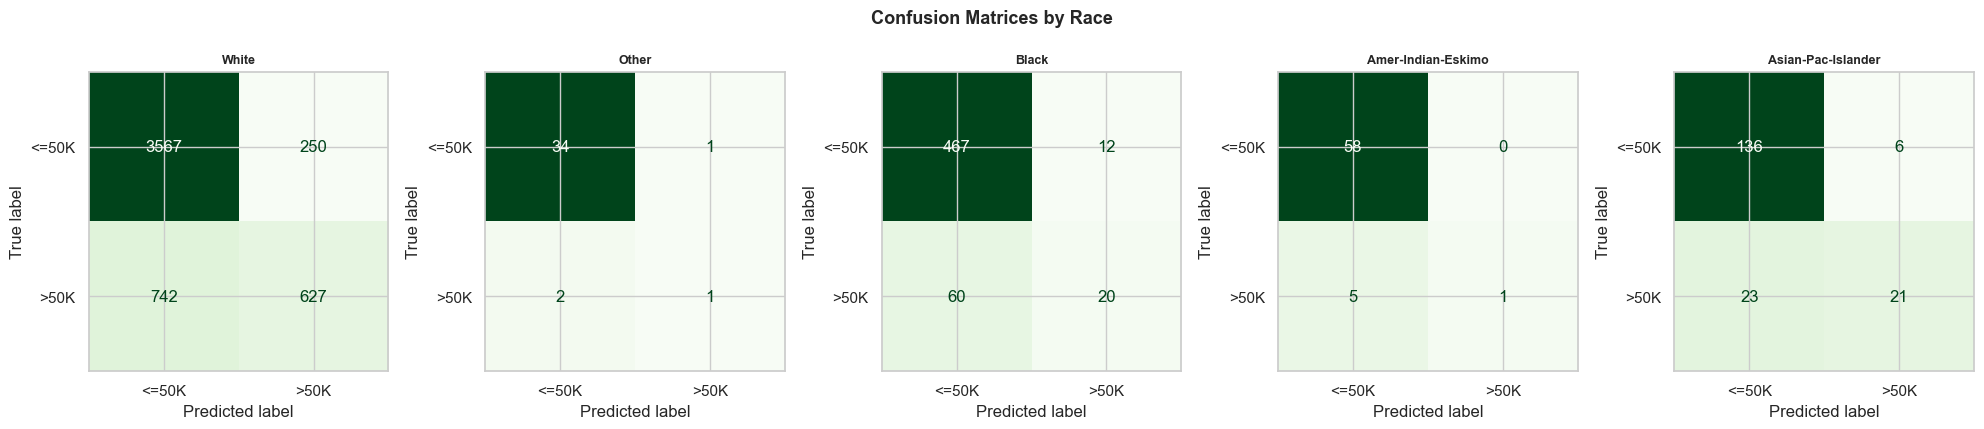

In [27]:
# Confusion matrices per race group 
race_groups = race_test.unique()
n_groups    = len(race_groups)

fig, axes = plt.subplots(1, n_groups, figsize=(4 * n_groups, 4))

for ax, group in zip(axes, race_groups):
    mask = (race_test == group).values
    cm_g = confusion_matrix(y_test.values[mask], y_pred[mask])
    ConfusionMatrixDisplay(
        confusion_matrix=cm_g,
        display_labels=['<=50K', '>50K']
    ).plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(f'{group}', fontweight='bold', fontsize=9)

plt.suptitle('Confusion Matrices by Race', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [28]:
#  Fairness metrics table for race 
race_metrics = {}

for group in race_groups:
    mask = (race_test == group).values
    race_metrics[group] = calculate_fairness_metrics(
        y_test.values[mask],
        y_pred[mask],
    )

race_df = pd.DataFrame(race_metrics).T
race_df.index.name = 'Group'

# Sort by subgroup size (largest first) for easier reading
race_df = race_df.sort_values('n', ascending=False)
race_df

,FPR,FNR,FDR,FOR,n
Group,,,,,
White,0.0655,0.5420,0.2851,0.1722,5186.0
Black,0.0251,0.7500,0.3750,0.1139,559.0
Asian-Pac-Islander,0.0423,0.5227,0.2222,0.1447,186.0
Amer-Indian-Eskimo,0.0000,0.8333,0.0000,0.0794,64.0
Other,0.0286,0.6667,0.5000,0.0556,38.0


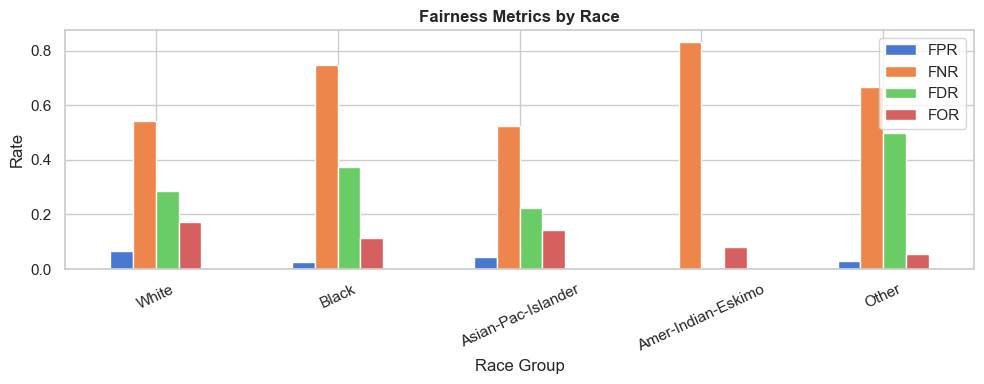

In [29]:
#  Bar chart — error rates by race
ax = race_df[metrics_cols].plot(
    kind='bar',
    figsize=(10, 4),
    rot=25,
    edgecolor='white',
)
ax.set_title('Fairness Metrics by Race', fontweight='bold')
ax.set_ylabel('Rate')
ax.set_xlabel('Race Group')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
## 8  |  Conclusion

### Summary of Findings

| Dimension | Key Disparity |
|-----------|---------------|
| **Sex**  | Women face a higher False Negative Rate — the model systematically under-predicts their high income. |
| **Race** | Black individuals also face elevated FNR; Asian-Pac-Islander individuals are more likely to receive false positives. |


### Limitations

1. **No causality** — we observe correlation, not causation. Disparities may reflect societal inequality embedded in historical data.
2. **Small subgroups** — some race categories have few samples, making metric estimates less reliable.
3. **No mitigation** — this notebook is diagnostic only. Techniques such as reweighting, resampling, or fairness-aware training were intentionally excluded.

